In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### carregar arquivo para o dataframe

In [3]:
df_exames = pd.read_csv('./datasets/exame_diabetes.csv')

### visualizar estrutura

In [4]:
df_exames.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   id_paciente  100 non-null    int64
 1   genero       100 non-null    str  
 2   idade        100 non-null    int64
 3   peso         100 non-null    int64
 4   altura       100 non-null    int64
 5   resultado    100 non-null    int64
dtypes: int64(5), str(1)
memory usage: 4.8 KB


### apresentar as 10 primeiras linhas

In [5]:
df_exames.head(10)

,id_paciente,genero,idade,peso,altura,resultado
0,1,M,46,83,165,98
1,2,F,23,83,164,82
2,3,M,39,71,154,93
3,4,F,26,103,165,95
4,5,M,27,55,176,100
5,6,M,64,93,190,117
6,7,F,21,70,182,90
7,8,F,60,101,179,84
8,9,F,63,83,189,92
9,10,F,65,78,175,121


In [6]:
df_exames.genero.unique()

<StringArray>
['M', 'F']
Length: 2, dtype: str

### remover coluna 'id_paciente'

In [7]:
## removendo a coluna id_paciente, pois não é relevante para o modelo
df_exames = df_exames.drop(columns=['id_paciente'])
df_exames.head()

,genero,idade,peso,altura,resultado
0,M,46,83,165,98
1,F,23,83,164,82
2,M,39,71,154,93
3,F,26,103,165,95
4,M,27,55,176,100


### converter uma variável categórica (genero) em númerica, usando one-hot encoding

In [8]:
## A coluna 'genero' é categórica, precisamos transformá-la em numérica para usar no modelo de machine learning
df_exames = pd.get_dummies(df_exames, columns=['genero'], dtype='int64')
df_exames.head()

,idade,peso,altura,resultado,genero_F,genero_M
0,46,83,165,98,0,1
1,23,83,164,82,1,0
2,39,71,154,93,0,1
3,26,103,165,95,1,0
4,27,55,176,100,0,1


In [9]:
df_exames.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   idade      100 non-null    int64
 1   peso       100 non-null    int64
 2   altura     100 non-null    int64
 3   resultado  100 non-null    int64
 4   genero_F   100 non-null    int64
 5   genero_M   100 non-null    int64
dtypes: int64(6)
memory usage: 4.8 KB


### apresentar mapa de calor com correlação entre variáveis

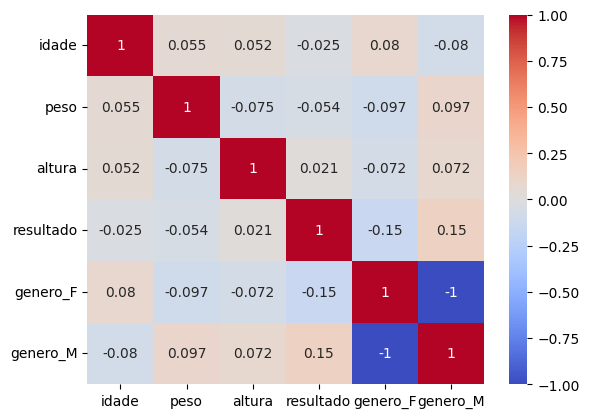

In [10]:
sns.heatmap(df_exames.corr(), vmin=-1, vmax=1,annot=True, cmap='coolwarm')
plt.show()

### apresentar mapa de correlação só com a variável target (resultado)

<Axes: >

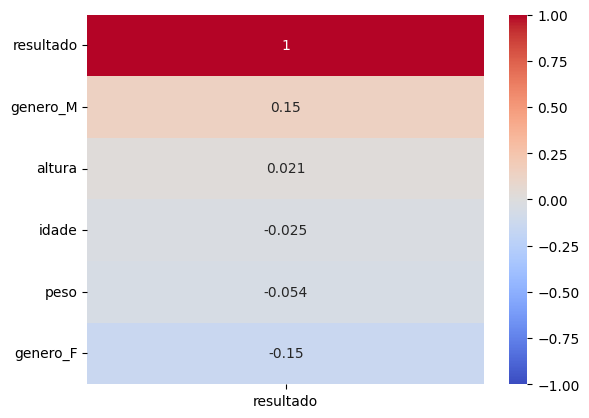

In [11]:
sns.heatmap(df_exames.corr()[['resultado']].sort_values(by='resultado', ascending=False), vmin=-1, vmax=1, annot=True, cmap='coolwarm')

### plot de scatter (dispersão) com distribuição

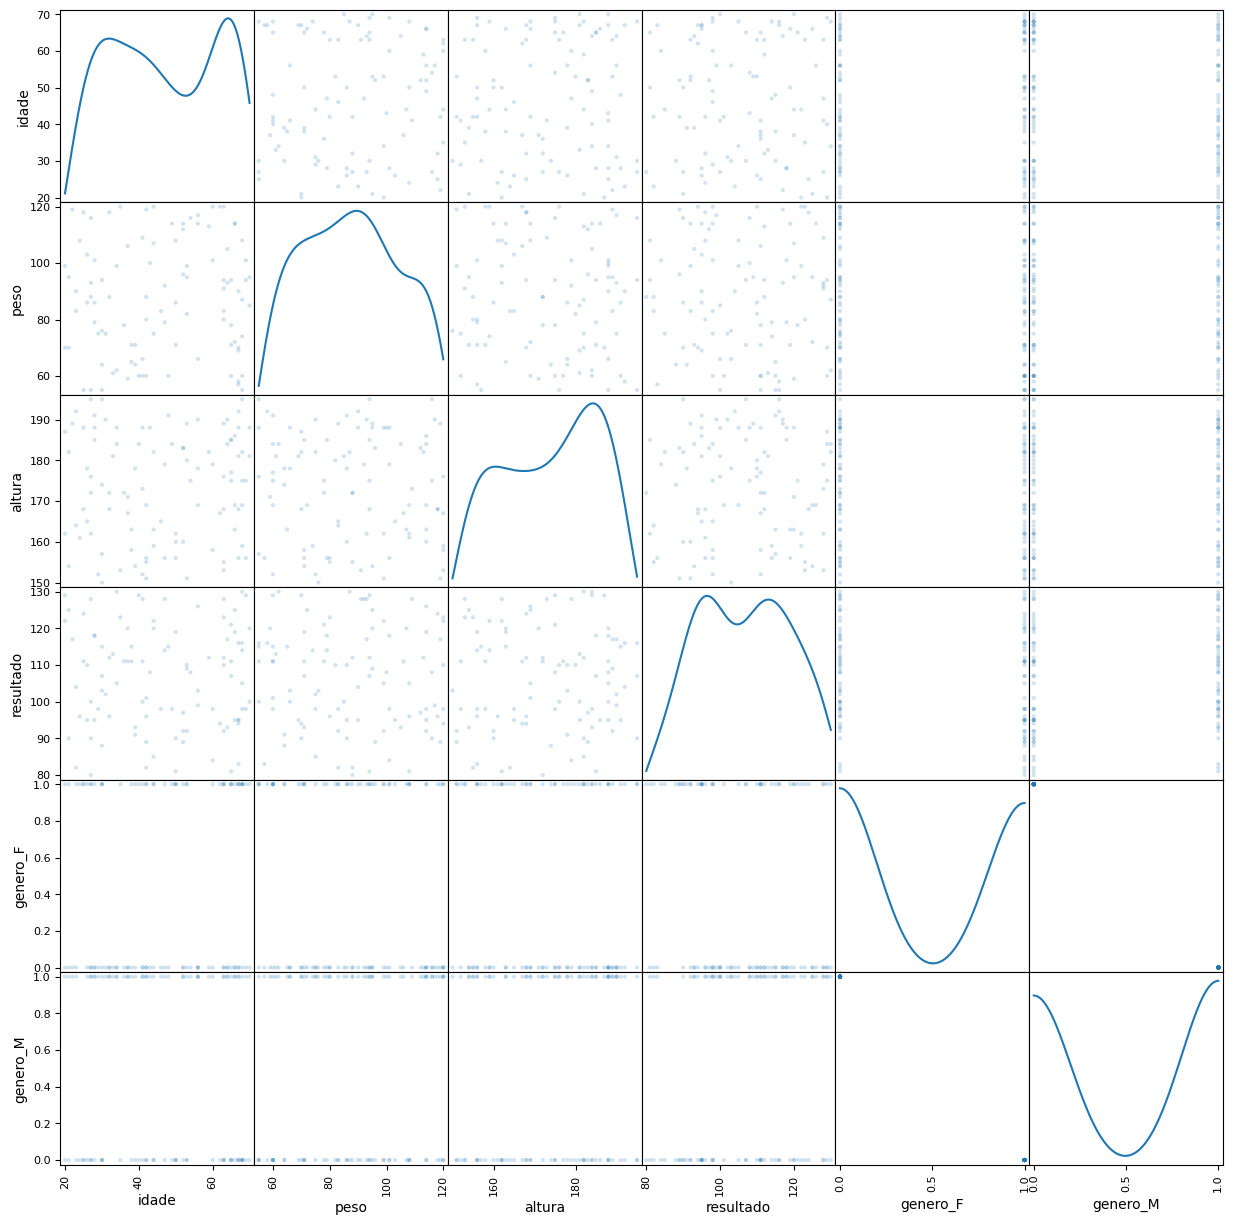

In [12]:
pd.plotting.scatter_matrix(df_exames, alpha=0.2, figsize=(15, 15), diagonal='kde')
plt.show()

### histograma de todas as variáveis

array([[<Axes: title={'center': 'idade'}>,
        <Axes: title={'center': 'peso'}>,
        <Axes: title={'center': 'altura'}>],
       [<Axes: title={'center': 'resultado'}>,
        <Axes: title={'center': 'genero_F'}>,
        <Axes: title={'center': 'genero_M'}>]], dtype=object)

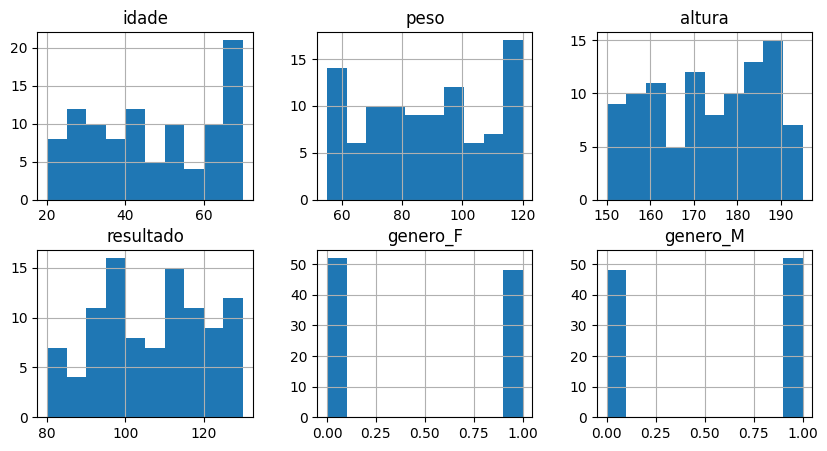

In [13]:
df_exames.hist(layout=(2, 3),figsize=(10, 5))

### criar uma feature nova

In [14]:
## criar a feature IMC (Índice de Massa Corporal) a partir do peso e altura
df_exames['imc'] = df_exames['peso'] / (df_exames['altura'] / 100) ** 2
df_exames.head()

,idade,peso,altura,resultado,genero_F,genero_M,imc
0,46,83,165,98,0,1,30.486685
1,23,83,164,82,1,0,30.859607
2,39,71,154,93,0,1,29.937595
3,26,103,165,95,1,0,37.832874
4,27,55,176,100,0,1,17.755682


In [15]:
df_exames.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   idade      100 non-null    int64  
 1   peso       100 non-null    int64  
 2   altura     100 non-null    int64  
 3   resultado  100 non-null    int64  
 4   genero_F   100 non-null    int64  
 5   genero_M   100 non-null    int64  
 6   imc        100 non-null    float64
dtypes: float64(1), int64(6)
memory usage: 5.6 KB


### atualização dos mapas e gráficos após criação da feature IMC

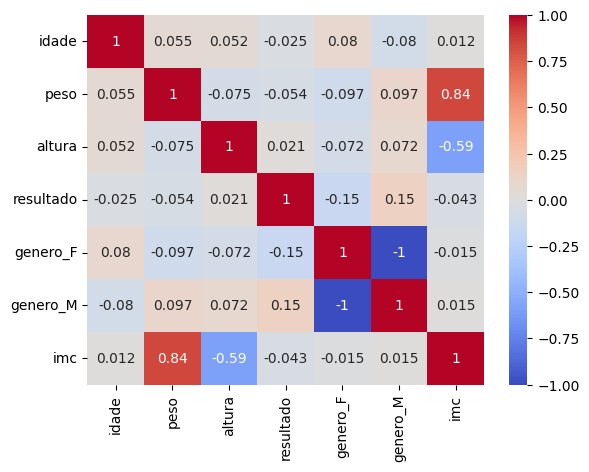

In [16]:
sns.heatmap(df_exames.corr(), vmin=-1, vmax=1,annot=True, cmap='coolwarm')
plt.show()

<Axes: >

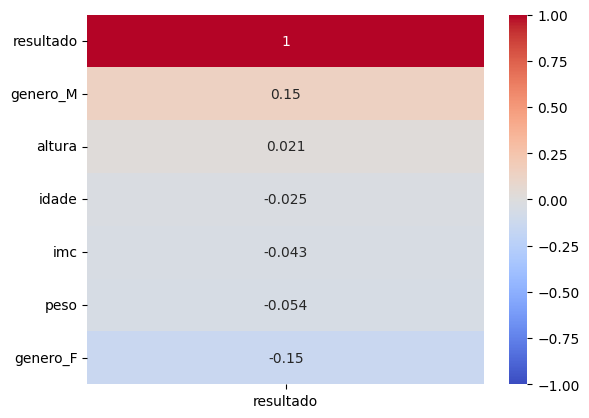

In [17]:
sns.heatmap(df_exames.corr()[['resultado']].sort_values(by='resultado', ascending=False), vmin=-1, vmax=1, annot=True, cmap='coolwarm')

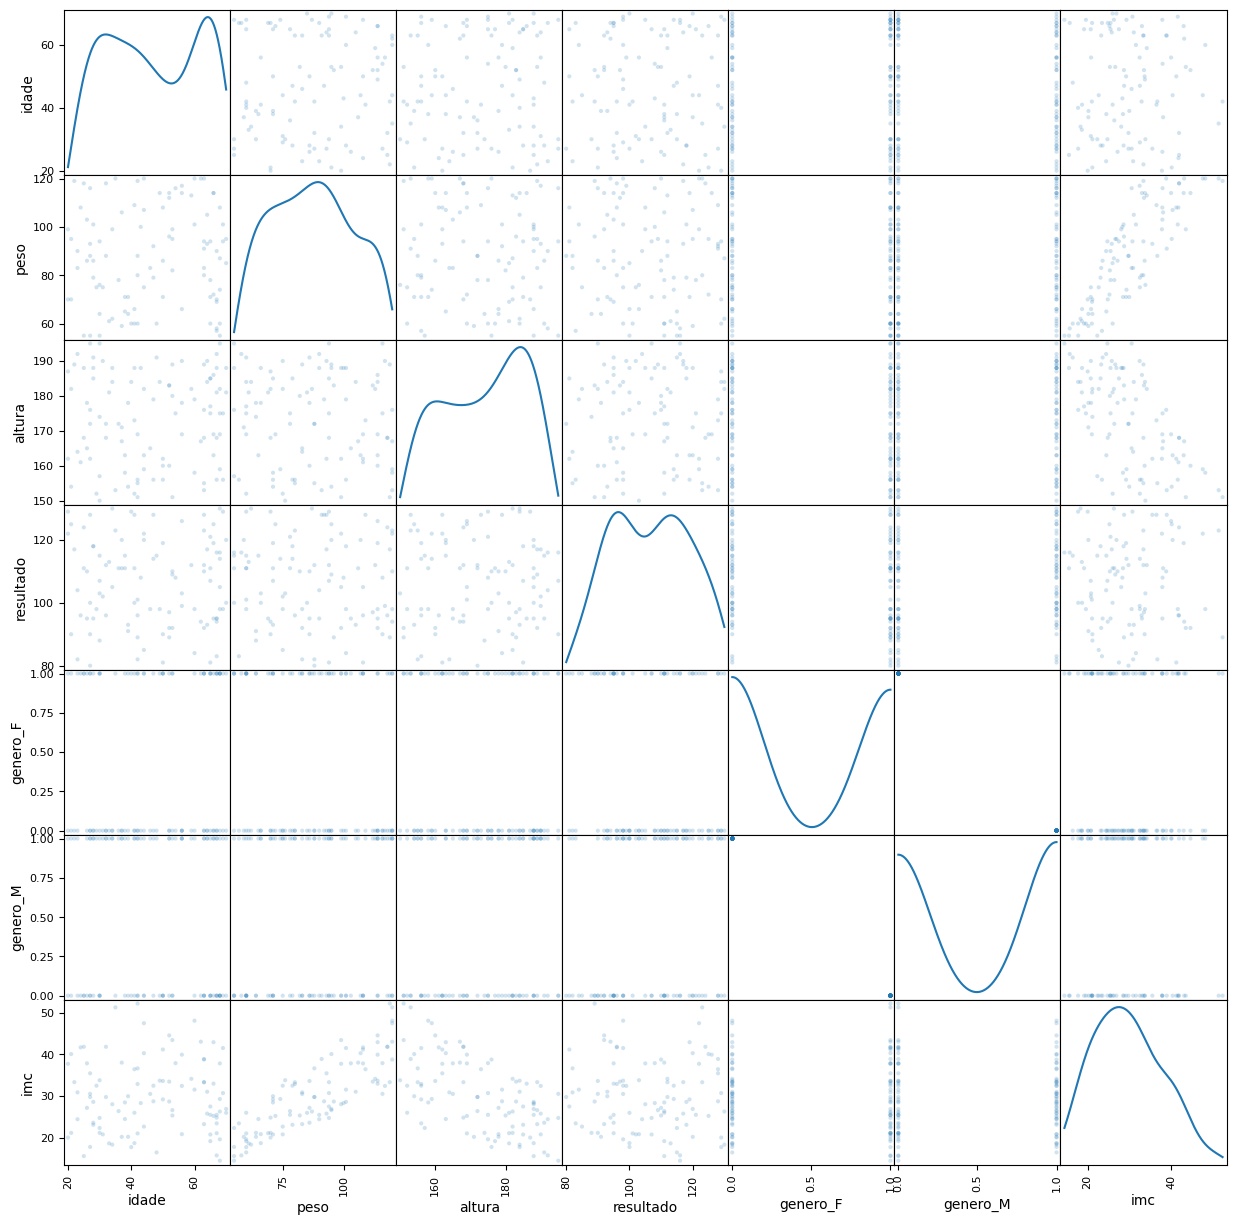

In [18]:
pd.plotting.scatter_matrix(df_exames, alpha=0.2, figsize=(15, 15), diagonal='kde')
plt.show()

array([[<Axes: title={'center': 'idade'}>,
        <Axes: title={'center': 'peso'}>,
        <Axes: title={'center': 'altura'}>,
        <Axes: title={'center': 'resultado'}>],
       [<Axes: title={'center': 'genero_F'}>,
        <Axes: title={'center': 'genero_M'}>,
        <Axes: title={'center': 'imc'}>, <Axes: >]], dtype=object)

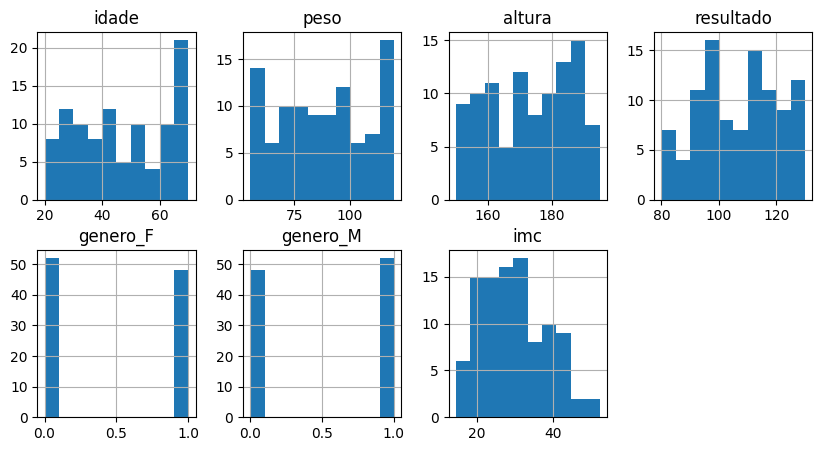

In [19]:
df_exames.hist(layout=(2, 4),figsize=(10, 5))

### importar bibliotecas do sklearn

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

### modelo 1 - sem IMC

In [21]:
### modelo 1 - sem IMC
X = df_exames.drop(columns=['imc', 'resultado'])
y = df_exames['resultado']

### dividir conjunto entre treino e teste

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=51)

### treinamento de modelo 1 - regressão linear

In [23]:
model_1 = LinearRegression().fit(X_train, y_train)

In [26]:
### gerar predições do conjunto de testes com base no modelo 1
y_pred_1 = model_1.predict(X_test)
y_pred_1

array([ 99.6684178 , 111.15467732, 113.11211654, 108.92788908,
       106.38206401, 107.30939688, 109.65461594, 112.00335574,
       111.06900447, 109.78672617, 112.35808062, 112.28232464,
       111.9380202 , 108.10634945,  98.35810505, 108.24066307,
       107.47444699, 107.86866238, 108.45528721, 106.47405474,
       108.68462818, 107.39800684, 105.52920918, 101.5310878 ,
       107.73027652, 103.02436766, 105.65307386, 112.03833836,
       105.49217347, 100.44933075])

In [27]:
### equação da reta de regressão (y = ax + b)
model_1.coef_, model_1.intercept_



(array([-0.00694816, -0.0788198 ,  0.10991808, -2.96913112,  2.96913112]),
 np.float64(94.21133142019875))